In [10]:
from astropy.io import fits

oiii_hdul = fits.open("SNR_OIII.fits")
oiiic_hdul = fits.open("SNR_OIIIC.fits")

oiii_data = oiii_hdul["SCI"].data
oiiic_data = oiiic_hdul["SCI"].data

oiii_header = oiii_hdul[0].header
oiiic_header = oiiic_hdul[0].header

In [11]:
# calculate exposure time
oiii_time_sec = oiii_header["EXPOSURE"] * oiii_header["NCOMBINE"] 
oiiic_time_sec = oiiic_header["EXPOSURE"] * oiiic_header["NCOMBINE"] 

print(oiii_time_sec, oiiic_time_sec)

6480.0 6480.0


In [14]:
# normalize images

oiii_data = oiii_data / oiii_time_sec
oiiic_data = oiiic_data / oiiic_time_sec

# update headers
oiii_header["EXPOSURE"] = 1
oiiic_header["EXPOSURE"] = 1

# save output
fits.writeto("normalized_OIII.fits", oiii_data, header=oiii_header, overwrite=True)
fits.writeto("normalized_OIIIC.fits", oiiic_data, header=oiiic_header, overwrite=True)

In [ ]:
# align images again
import astroalign as aa
import numpy as np


source = np.asarray(oiiic_data, dtype=np.float32)
target = np.asarray(oiii_data, dtype=np.float32)
aligned_OIIIC, footprint = aa.register(source, target)


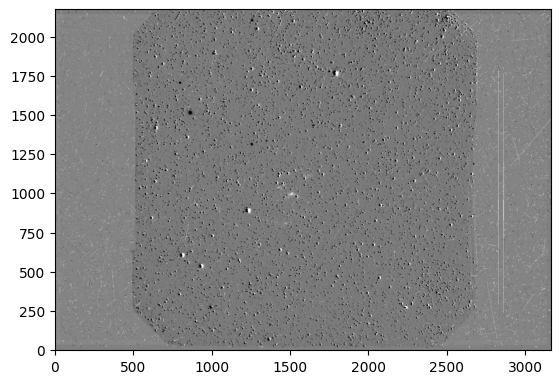

In [22]:
import matplotlib.pyplot as plt
import numpy as np

diff = oiii_data[:2174,] - oiiic_data * 0.5

plt.imshow(diff, cmap='gray', origin='lower', vmin=np.percentile(diff,1), vmax=np.percentile(diff,99.5))
plt.show()